# Eksperimen 3: Tes Arsitektur AttentiveSkel-3D
Notebook ini digunakan untuk memverifikasi bahwa arsitektur model `AttentiveSkel-3D` yang diimplementasikan di `model_3dcnn.py` dapat mengalirkan tensor tanpa error dimensi (*forward pass sanity check*).

**Yang diverifikasi:**
* Input dummy `(16, 64, 33, 3)` menghasilkan output `(16, 2)` ✓
* Semua dimensi tensor di setiap lapisan sesuai ekspektasi
* Jumlah parameter model
* Visualisasi bobot Biomechanical Spatial Prior (BSP) awal

### 1. Import Library & Konfigurasi

In [1]:
# ============================================================
# Import library dan daftarkan src/ ke sys.path
# ============================================================
import sys
import os
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Tambahkan direktori src/ ke Python path agar modul lokal dapat diimpor
sys.path.insert(0, os.path.abspath("../src"))

# Pastikan class AttentiveSkel3D dan fungsi count_parameters ada di file model_3dcnn.py
from models.model_3dcnn import AttentiveSkel3D, count_parameters

# Tentukan device (GPU jika tersedia, CPU jika tidak)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Import berhasil.")
print(f"PyTorch versi : {torch.version}")
print(f"Device aktif  : {DEVICE}")

Import berhasil.
PyTorch versi : <module 'torch.version' from 'c:\\Users\\Administrator\\anaconda3\\envs\\attentiveskel\\lib\\site-packages\\torch\\version.py'>
Device aktif  : cuda


### 2. Inisialisasi Model

In [2]:
# ============================================================
# Buat instance model dengan num_classes=2
# (kelas 0 = Gerakan Benar, kelas 1 = Gerakan Salah)
# ============================================================
model = AttentiveSkel3D(num_classes=2).to(DEVICE)

# Tampilkan ringkasan arsitektur model
print(model)
print()
print(f"Total parameter yang dapat dilatih: {count_parameters(model):,}")

AttentiveSkel3D(
  (conv_block_1): Sequential(
    (0): Conv3d(3, 32, kernel_size=(3, 3, 1), stride=(1, 1, 1), padding=(1, 1, 0), bias=False)
    (1): BatchNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool3d(kernel_size=(1, 2, 1), stride=(1, 2, 1), padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv3d(32, 64, kernel_size=(3, 3, 1), stride=(1, 1, 1), padding=(1, 1, 0), bias=False)
    (1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool3d(kernel_size=(2, 2, 1), stride=(2, 2, 1), padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_3): Sequential(
    (0): Conv3d(64, 128, kernel_size=(3, 3, 1), stride=(1, 1, 1), padding=(1, 1, 0), bias=False)
    (1): BatchNorm3d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (global_avg_pool): AdaptiveAvgPool3d(ou

### 3. Forward Pass Sanity Check dengan Dummy Tensor

In [3]:
# ============================================================
# Buat tensor dummy acak untuk mensimulasikan satu batch data.
# Dimensi:
# B=16 : Batch size 16 sampel video
# T=64 : 64 frame (hasil temporal resampling dari Fase 2)
# L=33 : 33 landmark pose BlazePose
# C=3  : Koordinat (x, y, z) ternormalisasi
# ============================================================
BATCH_SIZE = 16
dummy_input = torch.randn(BATCH_SIZE, 64, 33, 3).to(DEVICE)

print(f"Shape tensor input dummy : {dummy_input.shape}")
print(f" → (Batch={BATCH_SIZE}, Frame=64, Landmark=33, Koordinat=3)")

Shape tensor input dummy : torch.Size([16, 64, 33, 3])
 → (Batch=16, Frame=64, Landmark=33, Koordinat=3)


In [4]:
# ============================================================
# Jalankan forward pass dan periksa shape output.
# Tidak perlu hitung gradient untuk inferensi (lebih efisien).
# ============================================================
model.eval() # Set ke mode evaluasi (nonaktifkan Dropout)
with torch.no_grad():
    output = model(dummy_input)

print(f"Shape tensor output : {output.shape}")
print(f" → (Batch={output.shape[0]}, num_classes={output.shape[1]})")
print()

# Validasi otomatis shape output
expected_shape = (BATCH_SIZE, 2)
if tuple(output.shape) == expected_shape:
    print(f"[PASS] Shape output sesuai ekspektasi: {expected_shape}")
else:
    print(f"[FAIL] Shape output tidak sesuai! Diharapkan {expected_shape}, didapat {tuple(output.shape)}")

Shape tensor output : torch.Size([16, 2])
 → (Batch=16, num_classes=2)

[PASS] Shape output sesuai ekspektasi: (16, 2)


### 4. Profil Dimensi Tensor Per Lapisan

In [5]:
# ============================================================
# Lacak dan cetak dimensi tensor di setiap tahap forward pass
# secara manual untuk memastikan alur dimensi sudah benar.
# ============================================================
model.eval()
with torch.no_grad():
    x = dummy_input.clone()

print(f"{'Tahap':<45} {'Shape Tensor':>25}")
print("-" * 72)
print(f"{'[Input]':<45} {str(tuple(x.shape)):>25}")

# --- Reshape ---
x = x.permute(0, 3, 1, 2).unsqueeze(-1)
print(f"{'[Reshape] permute + unsqueeze':<45} {str(tuple(x.shape)):>25}")

# --- Biomechanical Spatial Prior ---
bsp = torch.sigmoid(model.biomechanical_spatial_prior)
x = x * bsp
print(f"{'[BSP] × Spatial Prior (sigmoid)':<45} {str(tuple(x.shape)):>25}")

# --- Conv Block 1 ---
x = model.conv_block_1(x)
print(f"{'[Conv Block 1] Conv→BN→ReLU→MaxPool(1,2,1)':<45} {str(tuple(x.shape)):>25}")

# --- Conv Block 2 ---
x = model.conv_block_2(x)
print(f"{'[Conv Block 2] Conv→BN→ReLU→MaxPool(2,2,1)':<45} {str(tuple(x.shape)):>25}")

# --- Conv Block 3 ---
x = model.conv_block_3(x)
print(f"{'[Conv Block 3] Conv→BN→ReLU':<45} {str(tuple(x.shape)):>25}")

# --- Global Average Pooling ---
x = model.global_avg_pool(x)
print(f"{'[Global Avg Pool] AdaptiveAvgPool3d(1,1,1)':<45} {str(tuple(x.shape)):>25}")

# --- Flatten ---
x = x.flatten(start_dim=1)
print(f"{'[Flatten]':<45} {str(tuple(x.shape)):>25}")

# --- Classifier ---
x = model.classifier(x)
print(f"{'[Classifier] Linear→ReLU→Dropout→Linear':<45} {str(tuple(x.shape)):>25}")
print("-" * 72)
print(f"{'[Output Logit]':<45} {str(tuple(x.shape)):>25}")

Tahap                                                      Shape Tensor
------------------------------------------------------------------------
[Input]                                                 (16, 64, 33, 3)
[Reshape] permute + unsqueeze                        (16, 3, 64, 33, 1)
[BSP] × Spatial Prior (sigmoid)                      (16, 3, 64, 33, 1)
[Conv Block 1] Conv→BN→ReLU→MaxPool(1,2,1)          (16, 32, 64, 16, 1)
[Conv Block 2] Conv→BN→ReLU→MaxPool(2,2,1)           (16, 64, 32, 8, 1)
[Conv Block 3] Conv→BN→ReLU                         (16, 128, 32, 8, 1)
[Global Avg Pool] AdaptiveAvgPool3d(1,1,1)           (16, 128, 1, 1, 1)
[Flatten]                                                     (16, 128)
[Classifier] Linear→ReLU→Dropout→Linear                         (16, 2)
------------------------------------------------------------------------
[Output Logit]                                                  (16, 2)


### 5. Visualisasi Biomechanical Spatial Prior (BSP)

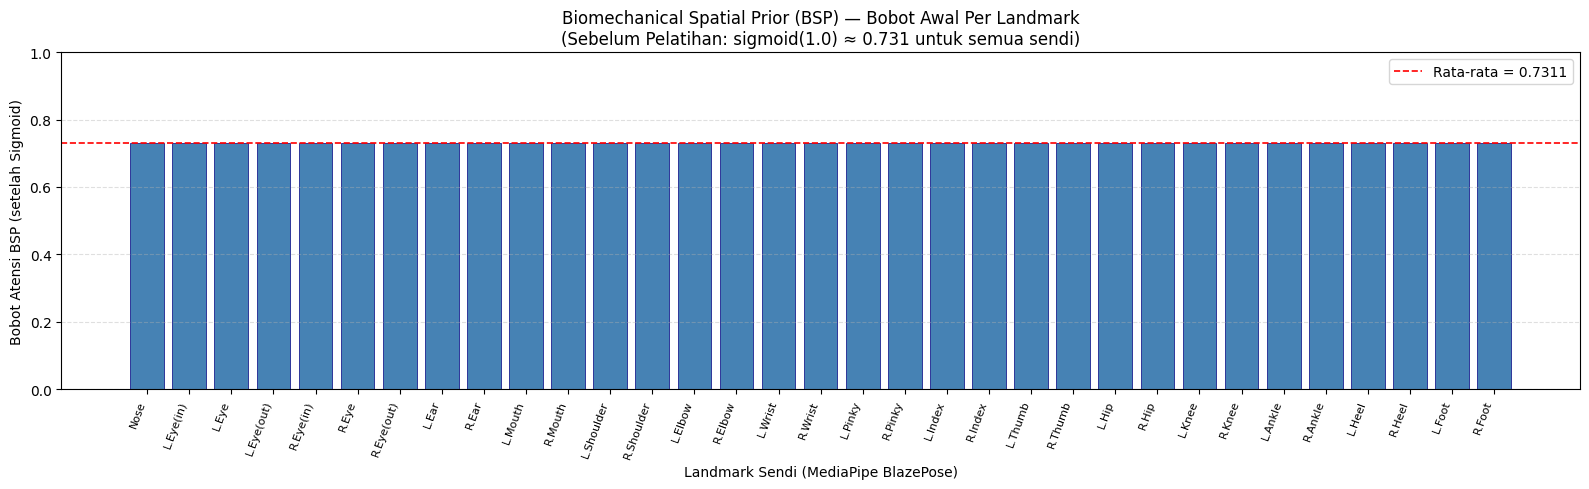


Nilai BSP awal (sigmoid(1.0)): 0.731059
Setelah pelatihan, nilai ini akan bervariasi antar sendi.


In [6]:
# ============================================================
# Visualisasikan bobot BSP awal (sebelum pelatihan).
# Karena diinisialisasi dengan nilai 1.0 dan dilewatkan sigmoid,
# semua bobot awal = sigmoid(1.0) ≈ 0.731.
# Setelah pelatihan, bobot ini akan bervariasi sesuai relevansi
# biomekanik masing-masing sendi untuk gerakan yang dideteksi.
# ============================================================

# Nama landmark MediaPipe BlazePose (33 landmark)
LANDMARK_NAMES = [
    "Nose", "L.Eye(in)", "L.Eye", "L.Eye(out)", "R.Eye(in)",
    "R.Eye", "R.Eye(out)", "L.Ear", "R.Ear", "L.Mouth", "R.Mouth",
    "L.Shoulder", "R.Shoulder", "L.Elbow", "R.Elbow",
    "L.Wrist", "R.Wrist", "L.Pinky", "R.Pinky",
    "L.Index", "R.Index", "L.Thumb", "R.Thumb",
    "L.Hip", "R.Hip", "L.Knee", "R.Knee",
    "L.Ankle", "R.Ankle", "L.Heel", "R.Heel",
    "L.Foot", "R.Foot",
]

# Ambil nilai bobot BSP setelah sigmoid
bsp_weights = torch.sigmoid(model.biomechanical_spatial_prior)
bsp_values = bsp_weights.squeeze().detach().cpu().numpy() # (33,)

# Plot bar chart bobot per sendi
fig, ax = plt.subplots(figsize=(16, 5))
bars = ax.bar(range(33), bsp_values, color="steelblue", edgecolor="navy", linewidth=0.5)
ax.set_xticks(range(33))
ax.set_xticklabels(LANDMARK_NAMES, rotation=70, ha="right", fontsize=8)
ax.set_ylim(0, 1.0)
ax.axhline(y=bsp_values.mean(), color="red", linestyle="--", linewidth=1.2,
           label=f"Rata-rata = {bsp_values.mean():.4f}")

ax.set_title("Biomechanical Spatial Prior (BSP) — Bobot Awal Per Landmark\n"
             "(Sebelum Pelatihan: sigmoid(1.0) ≈ 0.731 untuk semua sendi)", fontsize=12)
ax.set_xlabel("Landmark Sendi (MediaPipe BlazePose)")
ax.set_ylabel("Bobot Atensi BSP (setelah Sigmoid)")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

print(f"\nNilai BSP awal (sigmoid(1.0)): {bsp_values[0]:.6f}")
print("Setelah pelatihan, nilai ini akan bervariasi antar sendi.")

### 6. Ringkasan Model

In [7]:
# ============================================================
# Cetak ringkasan parameter model per komponen
# ============================================================
print(f"{'Komponen':<40} {'Parameter':>15}")
print("=" * 57)

# Pastikan nama variabel komponen di bawah ini sesuai dengan 
# nama yang dideklarasikan Agent di file model_3dcnn.py
components = {
    "Biomechanical Spatial Prior (BSP)": model.biomechanical_spatial_prior,
}
named_modules = {
    "Conv Block 1": model.conv_block_1,
    "Conv Block 2": model.conv_block_2,
    "Conv Block 3": model.conv_block_3,
    "Global Avg Pool": model.global_avg_pool,
    "Classifier Head": model.classifier,
}

for name, param in components.items():
    print(f"{name:<40} {param.numel():>15,}")
for name, module in named_modules.items():
    n_params = sum(p.numel() for p in module.parameters() if p.requires_grad)
    print(f"{name:<40} {n_params:>15,}")

print("-" * 57) 
total = count_parameters(model) 
print(f"{'TOTAL Parameter Trainable':<40} {total:>15,}") 
print() 

# Perbaikan perhitungan konversi ke Megabyte (Float32 = 4 bytes)
print(f"Ukuran model (float32): ≈ {total * 4 / (1024**2):.2f} MB")

Komponen                                       Parameter
Biomechanical Spatial Prior (BSP)                     33
Conv Block 1                                         928
Conv Block 2                                      18,560
Conv Block 3                                      73,984
Global Avg Pool                                        0
Classifier Head                                    8,386
---------------------------------------------------------
TOTAL Parameter Trainable                        101,891

Ukuran model (float32): ≈ 0.39 MB
